In [3]:
import sys
import os
# sys.path.append(os.path.abspath('../src'))

import torch
from models.emotion_classifier import EmotionClassifier
from utils.dataset import EmotionDataset
from torch.utils.data import DataLoader
from config.config import Config
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

Using device: cuda
Test Accuracy: 0.6219

Classification Report:
              precision    recall  f1-score   support

       Anger       0.41      0.35      0.38        40
     Disgust       0.59      0.61      0.60       132
   Enjoyment       0.70      0.67      0.68       193
        Fear       0.63      0.67      0.65        46
     Sadness       0.72      0.61      0.66       116
    Surprise       0.65      0.59      0.62        37
       Other       0.54      0.64      0.58       129

    accuracy                           0.62       693
   macro avg       0.60      0.59      0.60       693
weighted avg       0.63      0.62      0.62       693



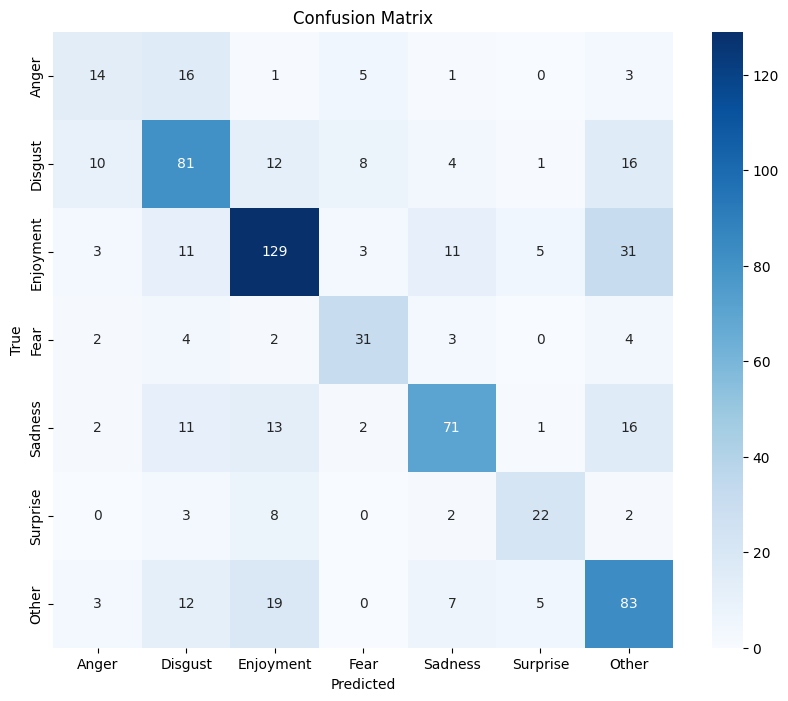


Error Analysis:

Text: người ta có bạn bè nhìn vui thật
True Emotion: Sadness
Predicted Emotion: Enjoyment

Text: cho nghỉ viêc mói đúng sao goi là kỷ luật
True Emotion: Surprise
Predicted Emotion: Disgust

Text: kinh vãi 😡
True Emotion: Disgust
Predicted Emotion: Fear

Text: bố không thích nộp đấy mày thích ý kiến không
True Emotion: Anger
Predicted Emotion: Other

Text: bắt cóc bỏ đĩa . quanh đi quẩn lại chỉ khổ dân đen thôi !
True Emotion: Other
Predicted Emotion: Disgust

Text: per trình mày vẫn còn thấp chán =))
True Emotion: Other
Predicted Emotion: Disgust

Text: ủa má . 2 đứa yêu nhau vô duyên và sân si giống nhau vậy ?
True Emotion: Disgust
Predicted Emotion: Surprise

Text: ổng quay thiệt mà sao chửi ổng thế . không quay sao máy bạn xem được đó :))
True Emotion: Other
Predicted Emotion: Surprise

Text: thần kinh cái đầu mày …
True Emotion: Disgust
Predicted Emotion: Fear

Text: nghe ngọt thế :((
True Emotion: Enjoyment
Predicted Emotion: Sadness


In [8]:

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load test dataset
test_dataset = EmotionDataset(
    "../src/data/test_data.xlsx",
    Config.MODEL_NAME,
    Config.MAX_LENGTH
)

test_loader = DataLoader(
    test_dataset,
    batch_size=Config.VALID_BATCH_SIZE,
    shuffle=False
)

# Load model
model = EmotionClassifier(Config.MODEL_NAME, Config.NUM_CLASSES)
model.load_state_dict(torch.load('../src/models/best_model.pth'))
model = model.to(device)
model.eval()

predictions = []
true_labels = []
sentences = []

# Test loop
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask)
        _, preds = torch.max(outputs, dim=1)
        
        predictions.extend(preds.cpu().tolist())
        true_labels.extend(labels.cpu().tolist())

# Calculate accuracy
accuracy = sum(1 for x, y in zip(predictions, true_labels) if x == y) / len(predictions)
print(f'Test Accuracy: {accuracy:.4f}')

# Print detailed classification report
label_names = ['Anger', 'Disgust', 'Enjoyment', 'Fear', 'Sadness', 'Surprise', 'Other']
print("\nClassification Report:")
print(classification_report(true_labels, predictions, target_names=label_names))

# Create confusion matrix
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, 
            yticklabels=label_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Error Analysis
test_data = pd.read_excel("../src/data/test_data.xlsx")
error_indices = [i for i, (p, t) in enumerate(zip(predictions, true_labels)) if p != t]

print("\nError Analysis:")
for idx in error_indices[:10]:  # Show first 10 errors
    print(f"\nText: {test_data.iloc[idx]['Sentence']}")
    print(f"True Emotion: {label_names[true_labels[idx]]}")
    print(f"Predicted Emotion: {label_names[predictions[idx]]}")